**Przetwarzanie strumieni danych lista 1 Oliwia Borkowska**

**Zad. 1** Bazując na bibliotece scipy.signal dostępnej dla języka Python wygeneruj następujące sygnały:

a) Sinus
b) Prostokątny
c) Piłokształtny
d) Świergotliwy
e) Superpozycja funkcji sinus i cosinus z samodzielnie dobranymi parametrami
f) Impuls jednostkowy

Zadanie dodatkowe: wygenerowane sygnały wyświetl w uporządkowany sposób korzystając z funkcji subplot. 

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import square, sawtooth, chirp, unit_impulse # zaimportowanie odpowiednich bibliotek

f = 1000 # częstotliwość (1/s = Hz), czyli 1000 próbek na sekundę
t = np.linspace(0, 1, f, endpoint=False) # wektor czasu podzielony na f, czyli 1000


**a) Sinus**

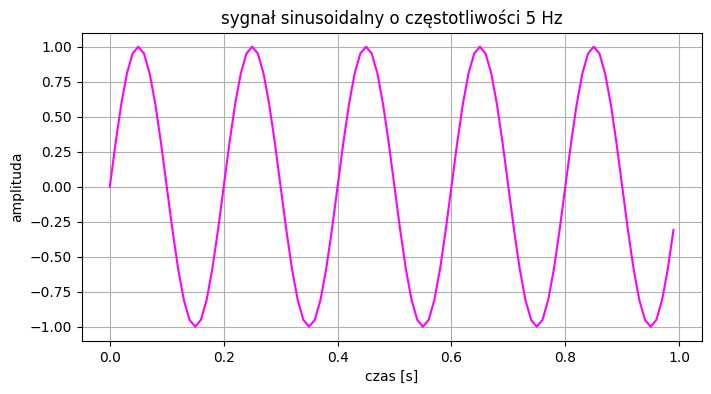

In [15]:
sinus = np.sin(2 * np.pi * 5 * t)
plt.figure(figsize=(8, 4))
plt.plot(t, sinus, color="magenta")
plt.title("sygnał sinusoidalny o częstotliwości 5 Hz")
plt.xlabel("czas [s]")
plt.ylabel("amplituda")
plt.grid()
plt.show()

**b) Prostokątny**

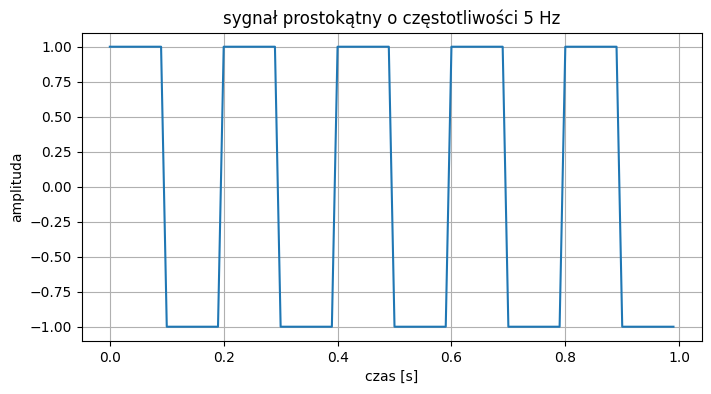

In [17]:
prostokatny = square(2 * np.pi * 5 * t)

plt.figure(figsize=(8, 4))
plt.plot(t, prostokatny)
plt.title("sygnał prostokątny o częstotliwości 5 Hz")
plt.xlabel("czas [s]")
plt.ylabel("amplituda")
plt.grid()
plt.show()


**c) Piłokształtny**

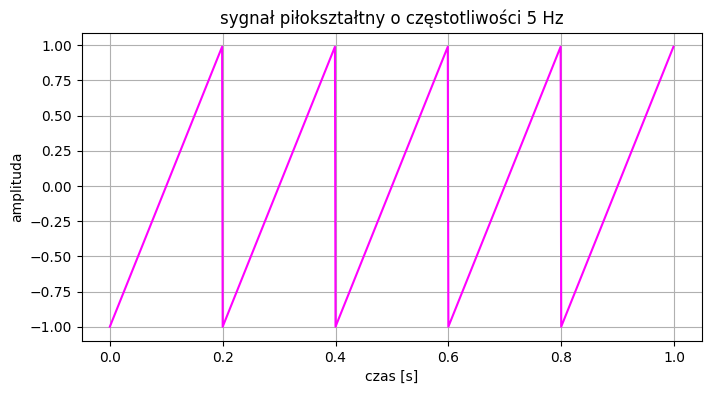

In [39]:
piloksztaltny = sawtooth(2 * np.pi * 5 * t)

plt.figure(figsize=(8, 4))
plt.plot(t, piloksztaltny, color="magenta")
plt.title("sygnał piłokształtny o częstotliwości 5 Hz")
plt.xlabel("czas [s]")
plt.ylabel("amplituda")
plt.grid()
plt.show()


d) **Świergotliwy** (zakres częśtotliwości od 1 Hz do 50 Hz w czasie 1 sekundy)

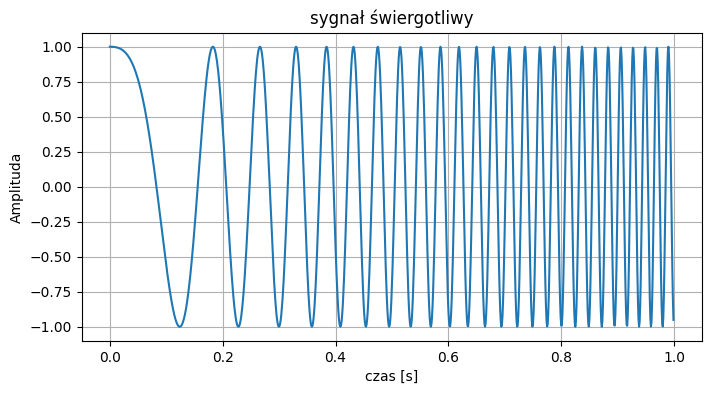

In [11]:
swiergotliwy = chirp(t, f0=1, f1=50, t1=1, method='linear') # zakładam, że częstotliwość wzrasta liniowo

plt.figure(figsize=(8, 4))
plt.plot(t, swiergotliwy)
plt.title("sygnał świergotliwy")
plt.xlabel("czas [s]")
plt.ylabel("amplituda")
plt.grid()
plt.show()

**e) Superpozycja funkcji sinus i cosinus z samodzielnie dobranymi parametrami**


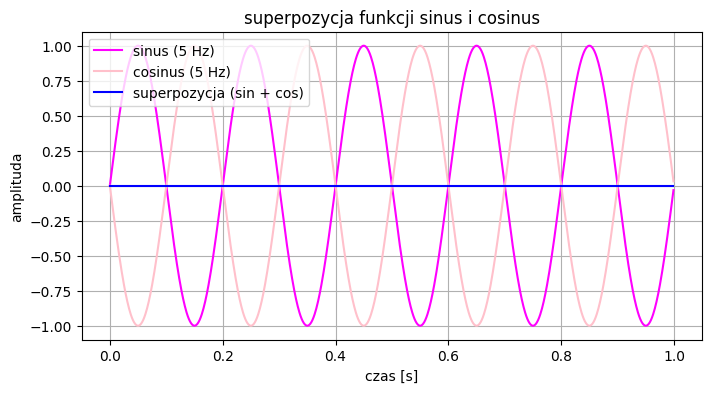

In [92]:
sinus = np.sin(2 * np.pi * 5 * t) # wybrana częstotliwość  - 5 Hz
cosinus = np.cos(2 * np.pi * 5 * t + np.pi * (1/2) ) # wybrana częstotliwość - 5 Hz oraz przesunięcie fazowe o 1/2 pi, tak, aby funkcje się "zniosły" i superpozycja była płaska
superpozycja = sinus + cosinus
 # Sinus
plt.figure(figsize=(8, 4))
plt.plot(t, sinus, label="sinus (5 Hz)", color="magenta")
plt.plot(t, cosinus, label="cosinus (5 Hz)", color="pink")
plt.plot(t, superpozycja, label="superpozycja (sin + cos)", color="blue")
plt.title("superpozycja funkcji sinus i cosinus")
plt.xlabel("czas [s]")
plt.ylabel("amplituda")
plt.grid()
plt.legend()
plt.show()

**f) Impuls jednostkowy - sygnał, który jest zerem wszędzie oprócz jendego punktu, gdzie wartość wynosi 1**


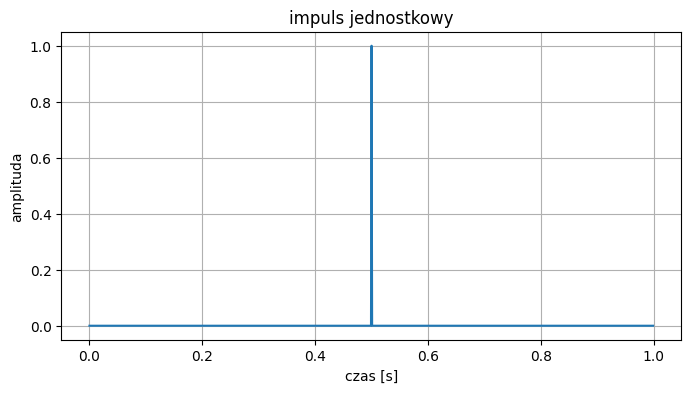

In [19]:
impuls = unit_impulse(f, idx= f//2) # idx wyznacz, w którym miejscu umieszczony zostanie impuls

plt.figure(figsize=(8, 4))
plt.plot(t, impuls)
plt.title("impuls jednostkowy")
plt.xlabel("czas [s]")
plt.ylabel("amplituda")
plt.grid()
plt.show()

In [18]:
signals = {
    "Sygnał sinusoidalny": sinus,
    "Sygnał prostokątny": prostokatny,
    "Sygnał piłokształtny": piloksztaltny,
    "Sygnał świergotliwy": swiergotliwy,
    "Superpozycja sinusa i cosinusa": superpozycja,
    "Impuls jednostkowy": impuls
    
}

with open('signals.pkl', 'wb') as f:
    pickle.dump(signals, f)

NameError: name 'piloksztaltny' is not defined

**Zad 2** Korzystając z funkcji read_csv dostępnej w bibliotece pandas wczytaj wybrane plik CSV z zapisem dowolnego sygnału.
 Dane ze strony: https://www.kaggle.com/datasets/protobioengineering/mit-bih-arrhythmia-database-modern-2023


   Column1    time_ms   MLII     V5
0        0   0.000000 -0.145 -0.065
1        1   2.777778 -0.145 -0.065
2        2   5.555556 -0.145 -0.065
3        3   8.333333 -0.145 -0.065
4        4  11.111111 -0.145 -0.065


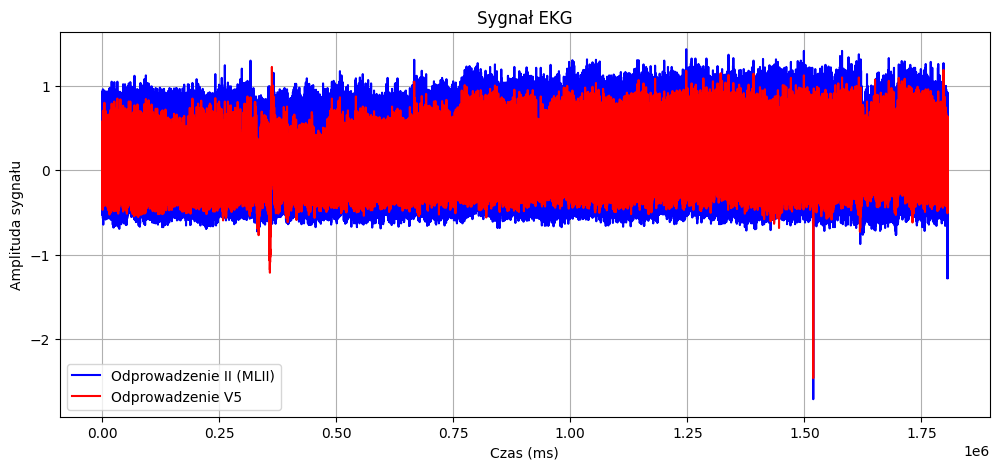

In [115]:

df_arrhytmia = pd.read_csv('arrhytmia.csv', sep=';')
print(df_arrhytmia.head())

plt.figure(figsize=(12, 5))
plt.plot(df_arrhytmia["time_ms"], df_arrhytmia["MLII"], label="odprowadzenie II (MLII)", color='blue')
plt.plot(df_arrhytmia["time_ms"], df_arrhytmia["V5"], label="odprowadzenie V5", color='red')

plt.xlabel("czas (ms)")
plt.ylabel("amplituda")
plt.title("sygnał EKG")
plt.legend()
plt.grid()
plt.show()

**Zad. 3** Korzystając z funkcji to_csv dostępnej w bibliotece pandas zapisz wybrany sygnał do pliku w formacie CSV. 

In [117]:
df_arrhytmia.to_csv("sygnal_EKG.csv", index=False, sep=";")
print("Zapisano pik csv.")

Zapisano pik csv.


**Zad. 3 wersja 2** Korzystając z funkcji to_csv dostępnej w bibliotece pandas zapisz wybrany sygnał do pliku w formacie CSV.  


Zapisano wcześniej utworzony sygnał sinus.

In [75]:
df = pd.DataFrame({'Czas': t, 'Amplituda': sinus})
df.to_csv('sygnal.csv', index=False, sep=';')
print("Zapisano pik csv.")

Zapisano pik csv.


**Zad. 2 wersja 2** Korzystając z funkcji read_csv dostępnej w bibliotece pandas wczytaj wybrane plik CSV z zapisem dowolnego sygnału.


    Czas  Amplituda
0  0.000   0.000000
1  0.001   0.031411
2  0.002   0.062791
3  0.003   0.094108
4  0.004   0.125333


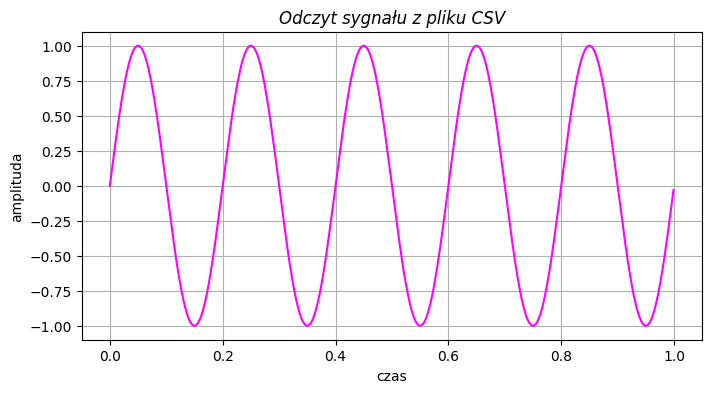

In [83]:
df_wczytywanie = pd.read_csv('sygnal.csv', sep=';')
print(df_wczytywanie.head())

czas = df_wczytywanie.iloc[:, 0]
amplituda = df_wczytywanie.iloc[:, 1]
plt.figure(figsize=(8, 4))
plt.plot(czas, amplituda, color='magenta')
plt.title('Odczyt sygnału z pliku CSV', style = 'italic')
plt.xlabel('czas')
plt.ylabel('amplituda')
plt.grid()
plt.show()

**Zad. 4** Korzystając z funkcji rand i randn, które dostępne są w bibliotece NumPy, wygeneruj przebiegi czasowe. Wyznacz histogramy dla tych przebiegów.

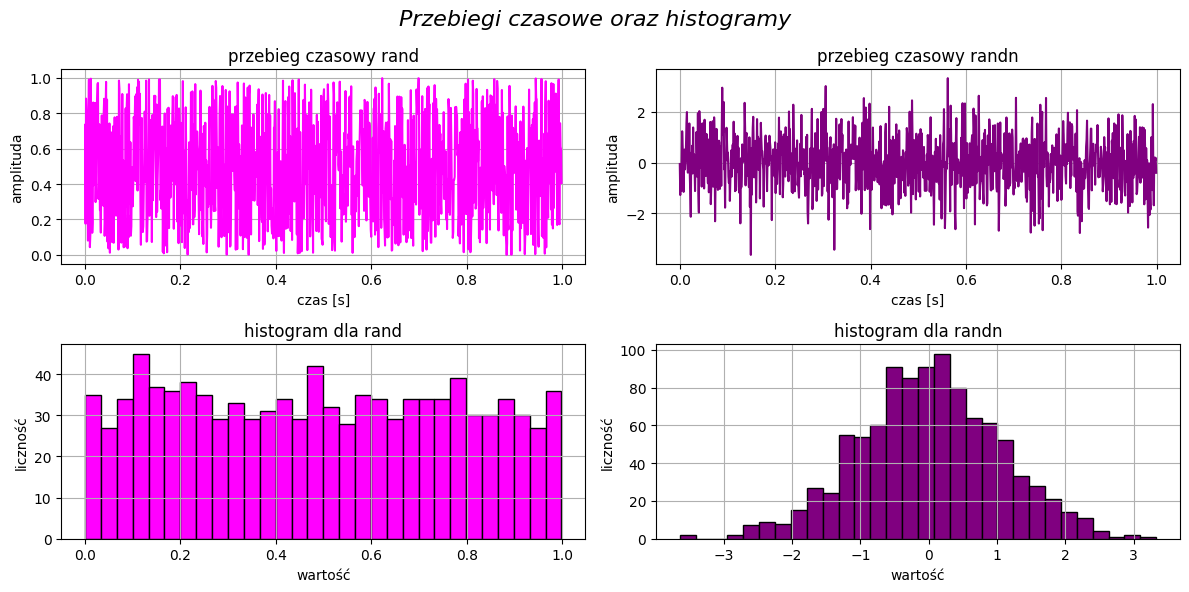

In [81]:
n = 1000 # rozmiar próbki
# rand - z rozkładu jednostajnego w zakresie [0,1]
przebieg_rand = np.random.rand(n)
# randn - z rozkładu normalnego o śr = 0 i odch. stand = 1
przebieg_randn = np.random.randn(n)


plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.plot(t, przebieg_rand, color='magenta')
plt.xlabel("czas [s]")
plt.ylabel("amplituda")
plt.title("przebieg czasowy rand")
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(t, przebieg_randn, color='purple')
plt.xlabel("czas [s]")
plt.ylabel("amplituda")
plt.title("przebieg czasowy randn")
plt.grid()

plt.subplot(2, 2, 3)
plt.hist(przebieg_rand, bins=30, color='magenta', edgecolor='black')
plt.xlabel("wartość")
plt.ylabel("liczność")
plt.title("histogram dla rand")
plt.grid()

plt.subplot(2, 2, 4)
plt.hist(przebieg_randn, bins=30, color='purple', edgecolor='black')
plt.xlabel("wartość")
plt.ylabel("liczność")
plt.title("histogram dla randn")
plt.grid()

plt.suptitle("Przebiegi czasowe oraz histogramy", fontsize=16, style ='italic')

plt.tight_layout()
plt.show()

**Zad. 5** Korzystając z funkcji random.normal, która dostępna jest w bibliotece NumPy, wygeneruj kilka przebiegów czasowych dla wybranych parametrów. Wyznacz histogramy dla tych przebiegów.

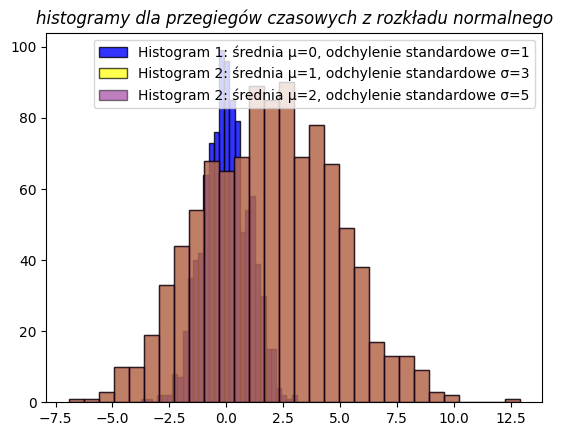

In [108]:
# parametry - loc = średnia, scale = odchylenie standardowe
dane_z_normal1 = np.random.normal(loc = 0, scale = 1, size = 1000) 
dane_z_normal2 = np.random.normal(loc = 2, scale = 3, size = 1000)


plt.hist(dane_z_normal1, bins = 30, alpha = 0.8, label = "Histogram 1: średnia μ=0, odchylenie standardowe σ=1", color = 'blue', edgecolor = 'black')

plt.hist(dane_z_normal2, bins = 30, alpha = 0.7, label = "Histogram 2: średnia μ=1, odchylenie standardowe σ=3", color = 'yellow', edgecolor = 'black')

plt.hist(dane_z_normal2, bins = 30, alpha = 0.5, label = "Histogram 2: średnia μ=2, odchylenie standardowe σ=5", color = 'purple', edgecolor = 'black')


plt.legend()
plt.title('histogramy dla przegiegów czasowych z rozkładu normalnego', style = 'italic')
plt.show()

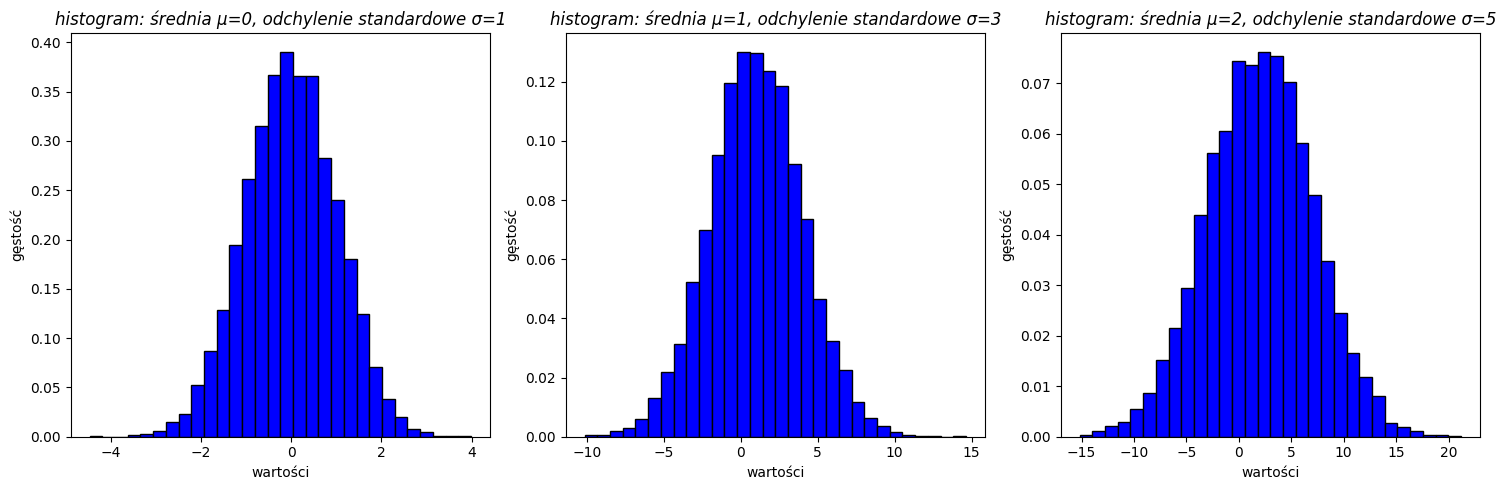

In [113]:
n = 10000
n_serii = 3
params = [(0, 1), (1, 3), (2, 5)]

time_series = [np.random.normal(mu, sigma, n) for mu, sigma in params]

fig, axes = plt.subplots(1, n_serii, figsize=(15, 5))
for i, (data, (mu, sigma)) in enumerate(zip(time_series, params)):
    axes[i].hist(data, bins=30, density=True, color='blue', edgecolor='black')
    axes[i].set_title(f'histogram: średnia μ={mu}, odchylenie standardowe σ={sigma}', style = 'italic')
    axes[i].set_xlabel('wartości')
    axes[i].set_ylabel('gęstość')

plt.tight_layout()
plt.show()


**Zad. 6** Przygotuj kod w języku Python, który generuje szum czerwony (Browna). Wyświetl histogram dla tego szumu.

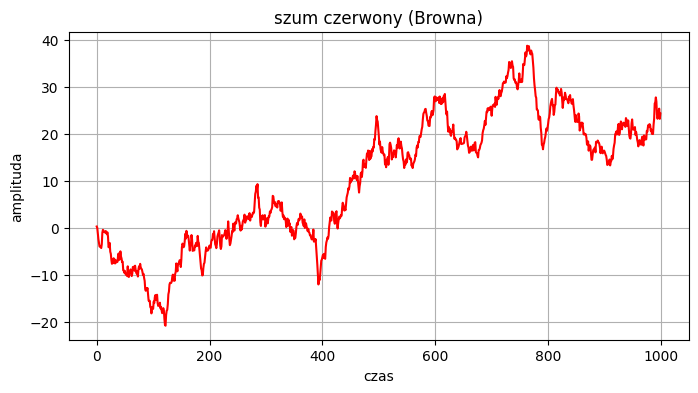

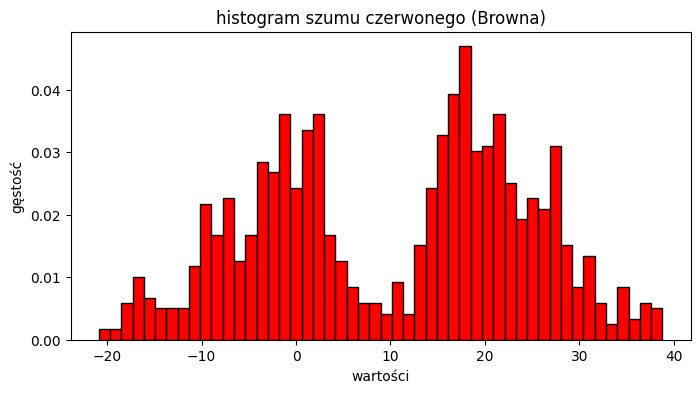

In [93]:
# szum biały to wartości losowe bez korelacji, a po ich skumulowaniu otrzymujemy szym czerowony
# szum czerwony może być wygenerowany przez scałkowanie szumu białego


n = 1000
white_noise = np.random.normal(0,1,n)
red_noise = np.cumsum(white_noise)

plt.figure(figsize=(8, 4))
plt.plot(red_noise, color='red')
plt.title('szum czerwony (Browna)')
plt.xlabel('czas')
plt.ylabel('amplituda')
plt.grid()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(red_noise, bins=50, density=True, color='red', edgecolor = 'black')
plt.title('histogram szumu czerwonego (Browna)')
plt.xlabel('wartości')
plt.ylabel('gęstość')
plt.show()

**Zad. 7** Przygotuj kod w języku Python, który generuje dwuwymiarowy szum czerwony (Browna). Wyświetl wygenerowany przebieg na płaszczyźnie

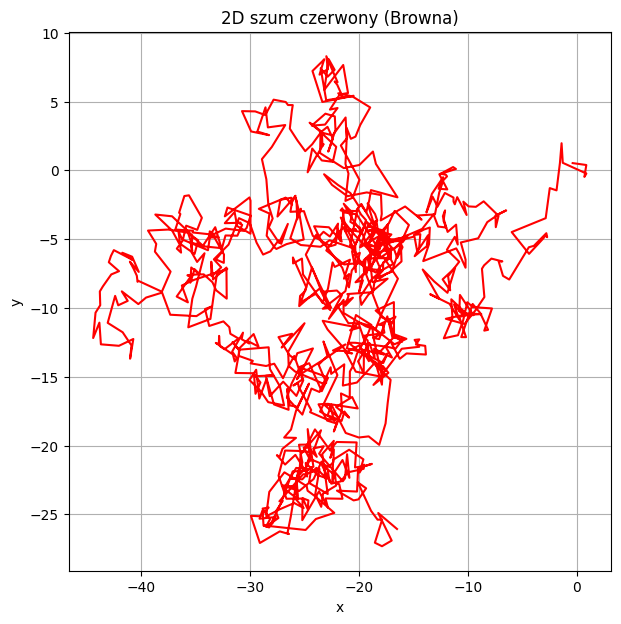

In [90]:
n = 1000

white_noise_x = np.random.normal(0, 1, n)
white_noise_y = np.random.normal(0, 1, n)

red_noise_x = np.cumsum(white_noise_x)
red_noise_y = np.cumsum(white_noise_y)

plt.figure(figsize=(7, 7))
plt.plot(red_noise_x, red_noise_y, color='red')
plt.title('2D szum czerwony (Browna)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()